In [2]:
!pip install diffusers accelerate

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install -q diffusers transformers accelerate

# Import libraries
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display
from PIL import Image
import uuid
import os
import ipywidgets as widgets
from IPython.display import display

# Setup directory


/content/drive/MyDrive/finetune_stable_diffusion


In [14]:
OUTPUT_DIR = "generated_images"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Load model
model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16 if device == "cuda" else torch.float32)
pipe.to(device)

print("\n")
print("****************************************************************************************************************************************")
print("\n")


# Function to generate and display image
def generate_and_display(prompt):
    if not prompt.strip():
        print("Please enter a valid prompt.")
        return

    print("Generating image...")

    image = pipe(prompt).images[0]

    filename = f"generated_image.png"
    image_path = os.path.join(OUTPUT_DIR, filename)
    image.save(image_path)

    print("Generated image:")
    display(image)

# Input textbox and button
text_box = widgets.Text(
    value='A red dress with floral designs',
    placeholder='Enter a dress description...',
    description='Prompt:',
    layout=widgets.Layout(width='80%')
)

generate_button = widgets.Button(
    description='Generate Image',
    button_style='success'
)

output = widgets.Output()

def on_button_click(b):
    with output:
        output.clear_output()
        generate_and_display(text_box.value)

generate_button.on_click(on_button_click)

# Display widgets
display(widgets.VBox([text_box, generate_button, output]))


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]



****************************************************************************************************************************************




In [15]:
from diffusers import AutoPipelineForInpainting, AutoencoderKL
from diffusers.utils import load_image
import torch

In [7]:
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipeline = AutoPipelineForInpainting.from_pretrained("diffusers/stable-diffusion-xl-1.0-inpainting-0.1", vae=vae, torch_dtype=torch.float16, variant="fp16", use_safetensors=True).to("cuda")
pipeline.load_ip_adapter("h94/IP-Adapter", subfolder="sdxl_models", weight_name="ip-adapter_sdxl.bin", low_cpu_mem_usage=True)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The config attributes {'decay': 0.9999, 'inv_gamma': 1.0, 'min_decay': 0.0, 'optimization_step': 37000, 'power': 0.6666666666666666, 'update_after_step': 0, 'use_ema_warmup': False} were passed to UNet2DConditionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


Saving 14529_00.jpg to 14529_00.jpg


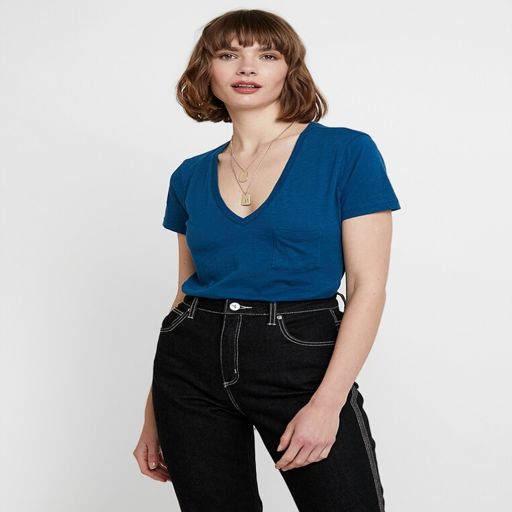

In [8]:
from PIL import Image
from google.colab import files
import io

# Upload image
uploaded = files.upload()

# Load and display uploaded image
for filename in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")
    resized_image = image.resize((512, 512))
    display(resized_image)


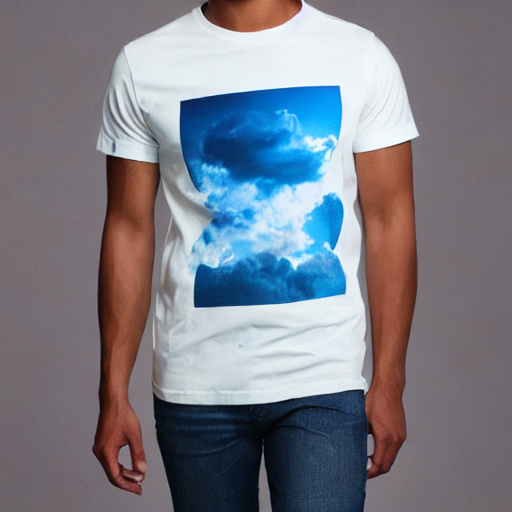

In [16]:
ip_image = load_image('/content/generated_images/generated_image.png').convert("RGB")
ip_image.resize((512, 512))

In [11]:
! git clone https://github.com/TonyAssi/Segment-Body.git
%cd /content/Segment-Body
! pip install -r requirements.txt
! cp ./SegBody.py ..
%cd ..

fatal: destination path 'Segment-Body' already exists and is not an empty directory.
/content/Segment-Body
/content


download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 108167.13KB/s]
/usr/local/lib/python3.11/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)


config.json:   0%|          | 0.00/1.73k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


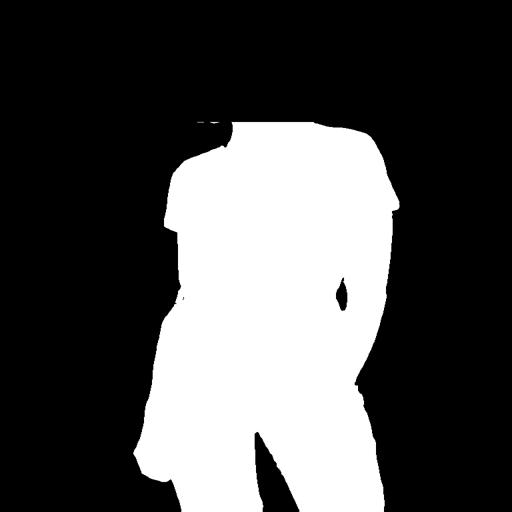

In [12]:
from SegBody import segment_body
seg_image, mask_image = segment_body(image, face=False)
mask_image.resize((512, 512))

  0%|          | 0/99 [00:00<?, ?it/s]

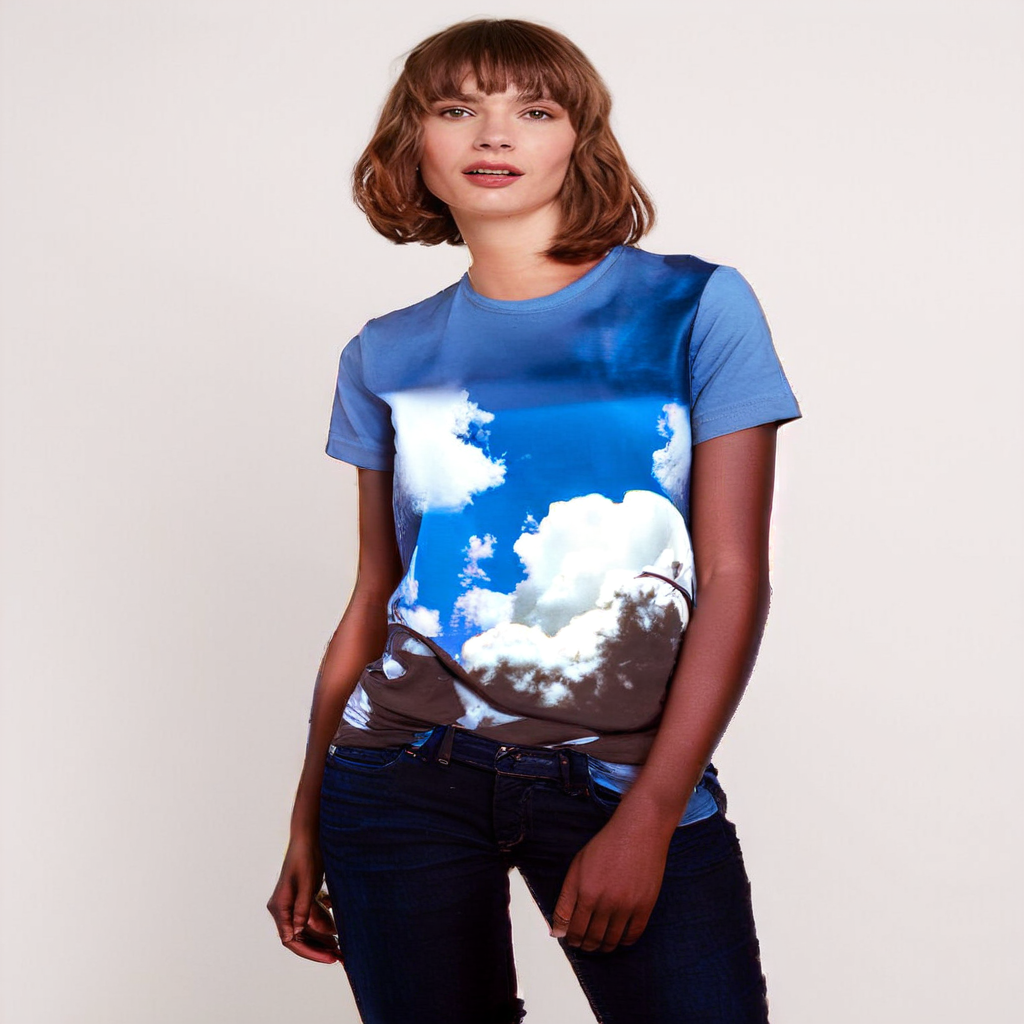

In [17]:
pipeline.set_ip_adapter_scale(1.0)
images = pipeline(
    prompt="photorealistic, perfect body, beautiful skin, realistic skin, natural skin",
    negative_prompt="ugly, bad quality, bad anatomy, deformed body, deformed hands, deformed feet, deformed face, deformed clothing, deformed skin, bad skin, leggings, tights, stockings",
    image=image,
    mask_image=mask_image,
    ip_adapter_image=ip_image,
    strength=0.99,
    guidance_scale=7.5,
    num_inference_steps=100,
).images
images[0]